<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
Deep Q-Network (DQN)

## **Aim**

To implement a Deep Q-Network (DQN) for the CartPole environment, evaluate the learned policy, and compare its performance with tabular Q-Learning.

## **Theory**

A Deep Q-Network (DQN) is a reinforcement learning algorithm that uses a neural network to approximate the Q-function.

Instead of storing Q-values in a table, DQN uses a neural network to estimate the value of each possible action for a given state.

The main components of DQN are:

1. Neural Network – approximates the Q-function.
2. Experience Replay – stores past experiences and randomly samples mini-batches for training.
3. Target Network – provides stable target Q-values during training.
4. ε-Greedy Policy – balances exploration and exploitation.

The DQN update target is:

Target = R + γ max Q_target(S', A')

The neural network is trained to minimize the difference between the predicted Q-value and the target value.

DQN is particularly useful when the state space is large or continuous, where maintaining a traditional Q-table becomes difficult.

In this experiment, DQN is applied to the CartPole environment. Its performance is then compared with tabular Q-Learning using a discretized version of the continuous CartPole state space.

## **Algorithm**

1. Create the CartPole environment.
2. Initialize the DQN neural network.
3. Initialize a target network with the same weights.
4. Create an experience replay buffer.
5. Set learning rate, discount factor, and ε-greedy parameters.
6. For each episode:
   - Reset the environment.
   - Select an action using the ε-greedy policy.
   - Execute the action.
   - Store the experience in the replay buffer.
   - Sample a mini-batch from the replay buffer.
   - Calculate target Q-values.
   - Train the neural network using the sampled experiences.
   - Periodically update the target network.
7. Gradually decrease ε to reduce exploration.
8. Evaluate the trained DQN using a greedy policy.
9. Discretize the CartPole state space.
10. Train a tabular Q-Learning agent on the discretized environment.
11. Compare the performance of DQN and tabular Q-Learning.
12. Plot the training rewards and final performance.

## **Install Required Libraries**

In [1]:
!pip install -q "gymnasium[classic-control]"

## **Import Libraries**

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from collections import deque

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.20.0
Libraries imported successfully.


## **Create CartPole Environment**

In [3]:
env = gym.make("CartPole-v1")

print("Environment:", env.spec.id)
print("State space:", env.observation_space)
print("Action space:", env.action_space)

print("\nState variables:")
print("0 = Cart Position")
print("1 = Cart Velocity")
print("2 = Pole Angle")
print("3 = Pole Angular Velocity")

print("\nActions:")
print("0 = Push Left")
print("1 = Push Right")

Environment: CartPole-v1
State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)

State variables:
0 = Cart Position
1 = Cart Velocity
2 = Pole Angle
3 = Pole Angular Velocity

Actions:
0 = Push Left
1 = Push Right


## **Define DQN Parameters**

In [4]:
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

gamma = 0.99
learning_rate = 0.001

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

batch_size = 64
memory_size = 50000

n_episodes = 300
target_update_frequency = 10

print("State size:", state_size)
print("Action size:", action_size)
print("Episodes:", n_episodes)

State size: 4
Action size: 2
Episodes: 300


## **Create Experience Replay Buffer**

In [5]:
from collections import deque

memory = deque(maxlen=memory_size)

print("Replay buffer created.")
print("Maximum experiences:", memory_size)

Replay buffer created.
Maximum experiences: 50000


## **Create DQN Neural Network**

In [6]:
# Convert these values explicitly to normal Python integers
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

def create_dqn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(state_size,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(int(action_size), activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=float(learning_rate)
        ),
        loss="mse"
    )

    return model


dqn = create_dqn()
target_dqn = create_dqn()

target_dqn.set_weights(dqn.get_weights())

dqn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,410 (68.01 KB)

 Trainable params: 17,410 (68.01 KB)

 Non-trainable params: 0 (0.00 B)

## **Define ε-Greedy Action Selection**

In [7]:
def choose_action(state, epsilon):
    if np.random.rand() <= epsilon:
        return np.random.randint(action_size)

    q_values = dqn.predict(state[np.newaxis, :], verbose=0)
    return int(np.argmax(q_values[0]))

## **Define Experience Replay Training**

In [8]:
def replay():
    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states = np.array([experience[0] for experience in batch], dtype=np.float32)
    actions = np.array([experience[1] for experience in batch])
    rewards = np.array([experience[2] for experience in batch], dtype=np.float32)
    next_states = np.array([experience[3] for experience in batch], dtype=np.float32)
    dones = np.array([experience[4] for experience in batch], dtype=np.float32)

    current_q = dqn.predict(states, verbose=0)
    next_q = target_dqn.predict(next_states, verbose=0)

    targets = current_q.copy()

    for i in range(batch_size):
        if dones[i]:
            targets[i, actions[i]] = rewards[i]
        else:
            targets[i, actions[i]] = rewards[i] + gamma * np.max(next_q[i])

    dqn.fit(states, targets, epochs=1, verbose=0)

## **Train DQN**

In [9]:
dqn_rewards = []
epsilon_history = []

n_episodes = 100

for episode in range(n_episodes):

    state, info = env.reset(seed=42 + episode)
    total_reward = 0
    done = False
    step_count = 0

    while not done:

        action = choose_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        memory.append((state, action, reward, next_state, done))

        state = next_state
        total_reward += reward
        step_count += 1

        # Train every 4 steps instead of every step
        if len(memory) >= batch_size and step_count % 4 == 0:
            replay()

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    if (episode + 1) % target_update_frequency == 0:
        target_dqn.set_weights(dqn.get_weights())

    dqn_rewards.append(total_reward)
    epsilon_history.append(epsilon)

    if (episode + 1) % 10 == 0:
        avg_reward = np.mean(dqn_rewards[-10:])

        print(
            f"Episode {episode + 1:3d} | "
            f"Average Reward: {avg_reward:6.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )

print("\nDQN training completed.")

Episode  10 | Average Reward:  19.70 | Epsilon: 0.951
Episode  20 | Average Reward:  17.40 | Epsilon: 0.905
Episode  30 | Average Reward:  18.90 | Epsilon: 0.860
Episode  40 | Average Reward:  18.70 | Epsilon: 0.818
Episode  50 | Average Reward:  21.90 | Epsilon: 0.778
Episode  60 | Average Reward:  26.20 | Epsilon: 0.740
Episode  70 | Average Reward:  31.30 | Epsilon: 0.704
Episode  80 | Average Reward:  35.50 | Epsilon: 0.670
Episode  90 | Average Reward:  66.80 | Epsilon: 0.637
Episode 100 | Average Reward:  44.20 | Epsilon: 0.606

DQN training completed.


## **Plot DQN Training Performance**

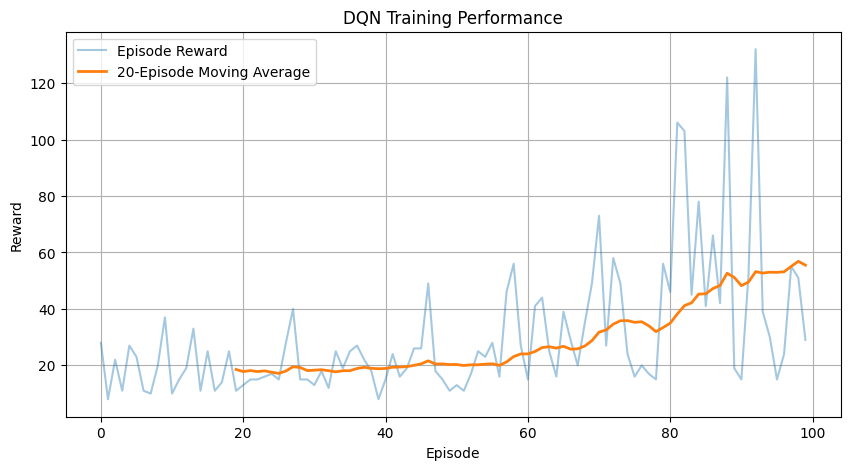

In [10]:
window = 20

dqn_moving_average = np.convolve(
    dqn_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(dqn_rewards, alpha=0.4, label="Episode Reward")
plt.plot(
    range(window - 1, len(dqn_rewards)),
    dqn_moving_average,
    linewidth=2,
    label="20-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Training Performance")
plt.legend()
plt.grid(True)
plt.show()

## **Evaluate Trained DQN**

In [12]:
def evaluate_dqn(episodes=10):

    rewards = []

    for episode in range(episodes):

        state, info = env.reset(seed=1000 + episode)
        total_reward = 0
        done = False

        while not done:

            q_values = dqn.predict(state[np.newaxis, :], verbose=0)
            action = int(np.argmax(q_values[0]))

            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated
            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return rewards


dqn_eval_rewards = evaluate_dqn(10)

print("DQN Evaluation Rewards:")
print(dqn_eval_rewards)

print("\nAverage DQN Reward:",
      round(np.mean(dqn_eval_rewards), 2))

DQN Evaluation Rewards:
[135.0, 118.0, 154.0, 109.0, 84.0, 105.0, 104.0, 116.0, 106.0, 85.0]

Average DQN Reward: 111.6


## **Discretize CartPole State Space**

In [13]:
# CartPole has a continuous state space.
# We divide each state variable into discrete intervals
# so that tabular Q-Learning can be applied.

bins = [
    np.linspace(-4.8, 4.8, 6),
    np.linspace(-5.0, 5.0, 6),
    np.linspace(-0.418, 0.418, 12),
    np.linspace(-5.0, 5.0, 12)
]

def discretize_state(state):
    state = np.clip(
        state,
        [-4.8, -5.0, -0.418, -5.0],
        [4.8, 5.0, 0.418, 5.0]
    )

    discrete_state = tuple(
        np.digitize(state[i], bins[i]) - 1
        for i in range(4)
    )

    return discrete_state


n_states = 6 * 6 * 12 * 12

q_table = np.zeros((n_states, action_size))

print("Discretized states:", n_states)
print("Actions:", action_size)
print("Q-table shape:", q_table.shape)

Discretized states: 5184
Actions: 2
Q-table shape: (5184, 2)


## **Convert Discrete State to Q-Table Index**

In [14]:
def state_to_index(state):
    index = 0

    for value, size in zip(state, [6, 6, 12, 12]):
        index = index * size + value

    return index


test_state, _ = env.reset(seed=123)
discrete_state = discretize_state(test_state)
state_index = state_to_index(discrete_state)

print("Original state:", test_state)
print("Discrete state:", discrete_state)
print("Q-table index:", state_index)

Original state: [ 0.01823519 -0.0446179  -0.02796401 -0.03156282]
Discrete state: (np.int64(2), np.int64(2), np.int64(5), np.int64(5))
Q-table index: 2081


## **Train Tabular Q-Learning**

In [15]:
alpha = 0.1
gamma_q = 0.99

epsilon_q = 1.0
epsilon_q_min = 0.01
epsilon_q_decay = 0.995

q_episodes = 300

q_rewards = []

for episode in range(q_episodes):

    state, info = env.reset(seed=2000 + episode)

    discrete_state = discretize_state(state)
    state_index = state_to_index(discrete_state)

    total_reward = 0
    done = False

    while not done:

        if np.random.rand() < epsilon_q:
            action = np.random.randint(action_size)
        else:
            action = int(np.argmax(q_table[state_index]))

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        next_discrete_state = discretize_state(next_state)
        next_state_index = state_to_index(next_discrete_state)

        if done:
            target = reward
        else:
            target = reward + gamma_q * np.max(q_table[next_state_index])

        q_table[state_index, action] += (
            alpha * (target - q_table[state_index, action])
        )

        state_index = next_state_index
        total_reward += reward

    if epsilon_q > epsilon_q_min:
        epsilon_q *= epsilon_q_decay

    q_rewards.append(total_reward)

    if (episode + 1) % 25 == 0:
        avg_reward = np.mean(q_rewards[-25:])
        print(
            f"Episode {episode + 1:3d} | "
            f"Average Reward: {avg_reward:6.2f} | "
            f"Epsilon: {epsilon_q:.3f}"
        )

print("\nTabular Q-Learning training completed.")

Episode  25 | Average Reward:  23.40 | Epsilon: 0.882
Episode  50 | Average Reward:  20.60 | Epsilon: 0.778
Episode  75 | Average Reward:  25.32 | Epsilon: 0.687
Episode 100 | Average Reward:  21.44 | Epsilon: 0.606
Episode 125 | Average Reward:  25.92 | Epsilon: 0.534
Episode 150 | Average Reward:  25.80 | Epsilon: 0.471
Episode 175 | Average Reward:  27.44 | Epsilon: 0.416
Episode 200 | Average Reward:  51.64 | Epsilon: 0.367
Episode 225 | Average Reward:  29.48 | Epsilon: 0.324
Episode 250 | Average Reward:  53.80 | Epsilon: 0.286
Episode 275 | Average Reward:  85.32 | Epsilon: 0.252
Episode 300 | Average Reward:  90.00 | Epsilon: 0.222

Tabular Q-Learning training completed.


## **Plot Q-Learning Performance**

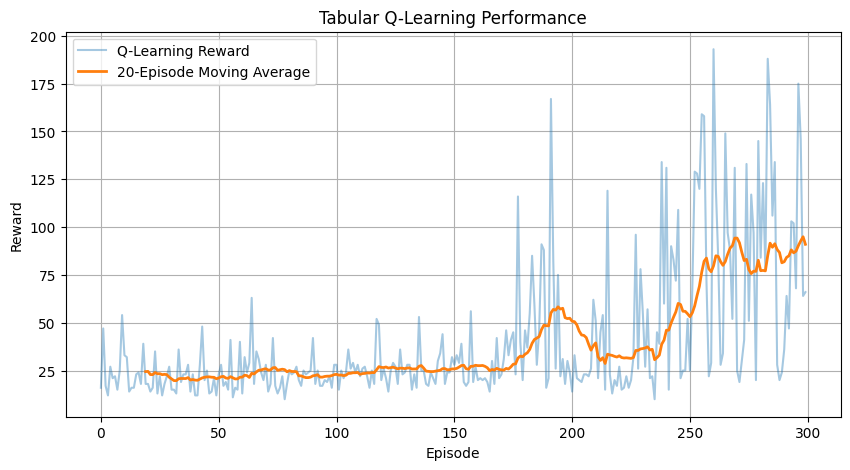

In [16]:
q_moving_average = np.convolve(
    q_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(q_rewards, alpha=0.4, label="Q-Learning Reward")
plt.plot(
    range(window - 1, len(q_rewards)),
    q_moving_average,
    linewidth=2,
    label="20-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Tabular Q-Learning Performance")
plt.legend()
plt.grid(True)
plt.show()

## **Evaluate Tabular Q-Learning**

In [17]:
def evaluate_q_learning(episodes=10):

    rewards = []

    for episode in range(episodes):

        state, info = env.reset(seed=3000 + episode)

        discrete_state = discretize_state(state)
        state_index = state_to_index(discrete_state)

        total_reward = 0
        done = False

        while not done:

            action = int(np.argmax(q_table[state_index]))

            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            next_discrete_state = discretize_state(next_state)
            state_index = state_to_index(next_discrete_state)

            total_reward += reward

        rewards.append(total_reward)

    return rewards


q_eval_rewards = evaluate_q_learning(10)

print("Q-Learning Evaluation Rewards:")
print(q_eval_rewards)

print("\nAverage Q-Learning Reward:",
      round(np.mean(q_eval_rewards), 2))

Q-Learning Evaluation Rewards:
[108.0, 116.0, 102.0, 87.0, 102.0, 124.0, 100.0, 98.0, 117.0, 99.0]

Average Q-Learning Reward: 105.3


## **Compare DQN and Q-Learning**

In [18]:
dqn_average = np.mean(dqn_eval_rewards)
q_average = np.mean(q_eval_rewards)

print("========== Final Comparison ==========")
print(f"DQN Average Reward          : {dqn_average:.2f}")
print(f"Q-Learning Average Reward   : {q_average:.2f}")

if dqn_average > q_average:
    print("\nDQN achieved the higher average evaluation reward.")
elif q_average > dqn_average:
    print("\nTabular Q-Learning achieved the higher average evaluation reward.")
else:
    print("\nBoth methods achieved the same average evaluation reward.")

========== Final Comparison ==========
DQN Average Reward          : 111.60
Q-Learning Average Reward   : 105.30

DQN achieved the higher average evaluation reward.


## **Visual Comparison**

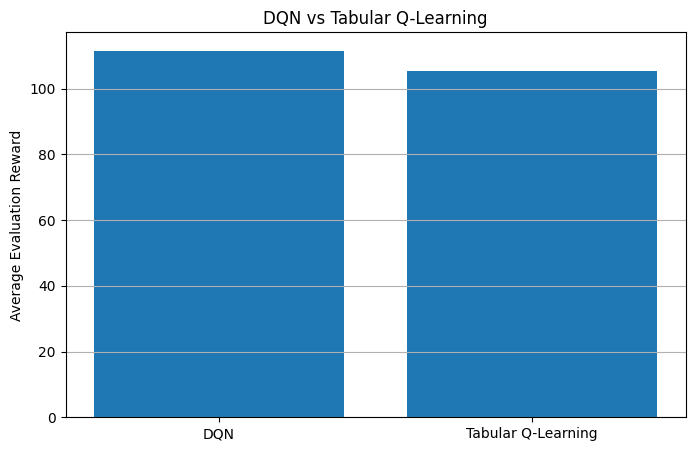

In [19]:
methods = ["DQN", "Tabular Q-Learning"]
scores = [dqn_average, q_average]

plt.figure(figsize=(8, 5))

plt.bar(methods, scores)

plt.ylabel("Average Evaluation Reward")
plt.title("DQN vs Tabular Q-Learning")
plt.grid(axis="y")

plt.show()

## **Display Final Results**

In [20]:
print("======================================")
print("       DQN EXPERIMENT RESULTS")
print("======================================")

print("\nDQN:")
print("Evaluation rewards:", dqn_eval_rewards)
print("Average reward:", round(dqn_average, 2))

print("\nTabular Q-Learning:")
print("Evaluation rewards:", q_eval_rewards)
print("Average reward:", round(q_average, 2))

print("\nBest performing method:")

if dqn_average > q_average:
    print("DQN")
elif q_average > dqn_average:
    print("Tabular Q-Learning")
else:
    print("Both methods performed equally.")

       DQN EXPERIMENT RESULTS

DQN:
Evaluation rewards: [135.0, 118.0, 154.0, 109.0, 84.0, 105.0, 104.0, 116.0, 106.0, 85.0]
Average reward: 111.6

Tabular Q-Learning:
Evaluation rewards: [108.0, 116.0, 102.0, 87.0, 102.0, 124.0, 100.0, 98.0, 117.0, 99.0]
Average reward: 105.3

Best performing method:
DQN


## **Observation**

1. DQN learns the CartPole task by using a neural network to approximate Q-values.

2. Experience replay helps the DQN learn from previously collected experiences.

3. The target network provides more stable Q-value targets during training.

4. The ε-greedy strategy allows the agent to explore different actions during training.

5. Tabular Q-Learning requires discretization because CartPole has a continuous state space.

6. The performance of DQN and tabular Q-Learning can be compared using their average evaluation rewards.

7. The method with the higher average evaluation reward performs better for the given experiment.

## **Conclusion**

The Deep Q-Network algorithm was successfully implemented on the CartPole environment. The DQN agent learned to select actions using a neural network, experience replay, a target network, and ε-greedy exploration.

The trained DQN was evaluated and its performance was compared with tabular Q-Learning using a discretized CartPole state space. The experiment demonstrates how deep reinforcement learning can handle continuous state spaces more effectively than a traditional Q-table.